# Importing Dependencies

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the Dataset

In [3]:
df=pd.read_csv('Dataset/MoviesOnStreamingPlatforms_updated.csv')

# Understanding the Data

In [4]:
df.columns

Index(['Unnamed: 0', 'ID', 'Title', 'Year', 'Age', 'IMDb', 'Rotten Tomatoes',
       'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Directors',
       'Genres', 'Country', 'Language', 'Runtime'],
      dtype='object')

In [5]:
df.head()

,Unnamed: 0,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Directors,Genres,Country,Language,Runtime
0,0,1,Inception,2010,13+,8.8,87%,1,0,0,0,0,Christopher Nolan,"Action,Adventure,Sci-Fi,Thriller","United States,United Kingdom","English,Japanese,French",148.0
1,1,2,The Matrix,1999,18+,8.7,87%,1,0,0,0,0,"Lana Wachowski,Lilly Wachowski","Action,Sci-Fi",United States,English,136.0
2,2,3,Avengers: Infinity War,2018,13+,8.5,84%,1,0,0,0,0,"Anthony Russo,Joe Russo","Action,Adventure,Sci-Fi",United States,English,149.0
3,3,4,Back to the Future,1985,7+,8.5,96%,1,0,0,0,0,Robert Zemeckis,"Adventure,Comedy,Sci-Fi",United States,English,116.0
4,4,5,"The Good, the Bad and the Ugly",1966,18+,8.8,97%,1,0,1,0,0,Sergio Leone,Western,"Italy,Spain,West Germany",Italian,161.0


In [6]:
df.tail()

,Unnamed: 0,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Directors,Genres,Country,Language,Runtime
16739,16739,16740,The Ghosts of Buxley Hall,1980,NaN,6.2,NaN,0,0,0,1,0,Bruce Bilson,"Comedy,Family,Fantasy,Horror",United States,English,120.0
16740,16740,16741,The Poof Point,2001,7+,4.7,NaN,0,0,0,1,0,Neal Israel,"Comedy,Family,Sci-Fi",United States,English,90.0
16741,16741,16742,Sharks of Lost Island,2013,NaN,5.7,NaN,0,0,0,1,0,Neil Gelinas,Documentary,United States,English,NaN
16742,16742,16743,Man Among Cheetahs,2017,NaN,6.6,NaN,0,0,0,1,0,Richard Slater-Jones,Documentary,United States,English,NaN
16743,16743,16744,In Beaver Valley,1950,NaN,NaN,NaN,0,0,0,1,0,James Algar,"Documentary,Short,Family",United States,English,32.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16744 entries, 0 to 16743
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       16744 non-null  int64  
 1   ID               16744 non-null  int64  
 2   Title            16744 non-null  object 
 3   Year             16744 non-null  int64  
 4   Age              7354 non-null   object 
 5   IMDb             16173 non-null  float64
 6   Rotten Tomatoes  5158 non-null   object 
 7   Netflix          16744 non-null  int64  
 8   Hulu             16744 non-null  int64  
 9   Prime Video      16744 non-null  int64  
 10  Disney+          16744 non-null  int64  
 11  Type             16744 non-null  int64  
 12  Directors        16018 non-null  object 
 13  Genres           16469 non-null  object 
 14  Country          16309 non-null  object 
 15  Language         16130 non-null  object 
 16  Runtime          16152 non-null  float64
dtypes: float64(2

# Data Cleaning

In [8]:
df.duplicated().any()

np.False_

In [9]:
df['Age']=df['Age'].fillna(df['Age'].mode()[0])
df['Rotten Tomatoes']=df['Rotten Tomatoes'].fillna(df['Rotten Tomatoes'].mode()[0])
df['IMDb']=df['IMDb'].fillna(df['IMDb'].mean()).round(1)
df['Runtime']=df['Runtime'].fillna(df['Runtime'].mean()).round(1)
for i in ['Directors','Genres','Country','Language']:
    df[i]=df[i].fillna('Unknown')
df['Rotten Tomatoes']=(df['Rotten Tomatoes'].str.strip('%').astype(float)/10).round(1)

In [10]:
df=df.drop(columns=['Unnamed: 0','ID','Type'])


# Data Transformation

In [11]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
df['Platform_Count'] = df[platforms].sum(axis=1)



In [12]:
def rating_category(r):
    if r >= 8:
        return 'Excellent'
    elif r >= 6:
        return 'Good'
    elif r >= 4:
        return 'Average'
    else:
        return 'Poor'

df['IMDb_Category'] = df['IMDb'].apply(rating_category)


In [13]:
def runtime_category(rt):
    if rt < 90:
        return 'Short'
    elif rt <= 150:
        return 'Medium'
    else:
        return 'Long'

df['Runtime_Category'] = df['Runtime'].apply(runtime_category)


# Data Analysis

How many movies are there in this dataset

In [14]:
df.shape[0]

16744

Which Year most movies were released

In [15]:
df['Year'].value_counts().head(1)


Year
2017    1401
Name: count, dtype: int64

Number of movies in each platform

In [16]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
df[platforms].sum().sort_values(ascending=False)

Prime Video    12354
Netflix         3560
Hulu             903
Disney+          564
dtype: int64

Average IMDb rating per platform

In [17]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
platform_ratings = {}
for p in platforms:
    platform_ratings[p] = df[df[p] == 1]['IMDb'].mean().round(1)
platform_ratings

{'Netflix': np.float64(6.2),
 'Hulu': np.float64(6.1),
 'Prime Video': np.float64(5.8),
 'Disney+': np.float64(6.4)}

Average Rotten Tomatoes rating per platform

In [18]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
platform_ratings = {}
for p in platforms:
    platform_ratings[p] = df[df[p] == 1]['Rotten Tomatoes'].mean().round(1)
platform_ratings

{'Netflix': np.float64(8.6),
 'Hulu': np.float64(7.7),
 'Prime Video': np.float64(9.1),
 'Disney+': np.float64(7.8)}

Compare both the ratings to find movies where audience and critics disagree

In [19]:
top_audience_favored = (df
    .assign(Rating_Diff = df['IMDb'] - df['Rotten Tomatoes'])
    .sort_values('Rating_Diff', ascending=False)
    .head(10)[['Title','IMDb','Rotten Tomatoes']]
)
top_audience_favored


,Title,IMDb,Rotten Tomatoes
3974,House of D,7.0,1.0
1801,The Black Prince,6.6,0.7
6308,A Little Bit of Heaven,6.3,0.4
6536,CBGB,6.6,0.7
1218,Raajneeti,7.1,1.3
7000,If I Were You,7.0,1.3
5489,Twice Born,7.4,1.7
4081,Black Gold,6.7,1.1
4541,The Boondock Saints,7.8,2.2
9735,Pilgrim Song,7.4,2.0


In [20]:
top_critics_favored = (df
    .assign(Rating_Diff = df['IMDb'] - df['Rotten Tomatoes'])
    .sort_values('Rating_Diff')
    .head(10)[['Title','IMDb','Rotten Tomatoes']]
)
top_critics_favored


,Title,IMDb,Rotten Tomatoes
13813,In Memoriam Alexander Litvinenko,0.0,10.0
13821,From Philadelphia To Fallujah,0.0,10.0
4359,9/11: 15 years later,0.0,10.0
10613,Capture,0.0,10.0
13681,Justin Bieber: Rise to Fame,1.0,10.0
15376,Justin Bieber: Always Believing,1.0,10.0
15071,Shark Exorcist,1.3,10.0
13933,Return of the Boogeyman,1.4,10.0
14307,Bigfoot vs. D.B. Cooper,1.4,10.0
14682,The Frog Prince,1.4,10.0


Average Runtime per platforms

In [21]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
platform_ratings = {}
for p in platforms:
    platform_ratings[p] = df[df[p] == 1]['Runtime'].mean().round(1)
platform_ratings

{'Netflix': np.float64(98.6),
 'Hulu': np.float64(97.3),
 'Prime Video': np.float64(92.3),
 'Disney+': np.float64(90.5)}

# Plots

1.How many movies were released each year? (Trend over time)

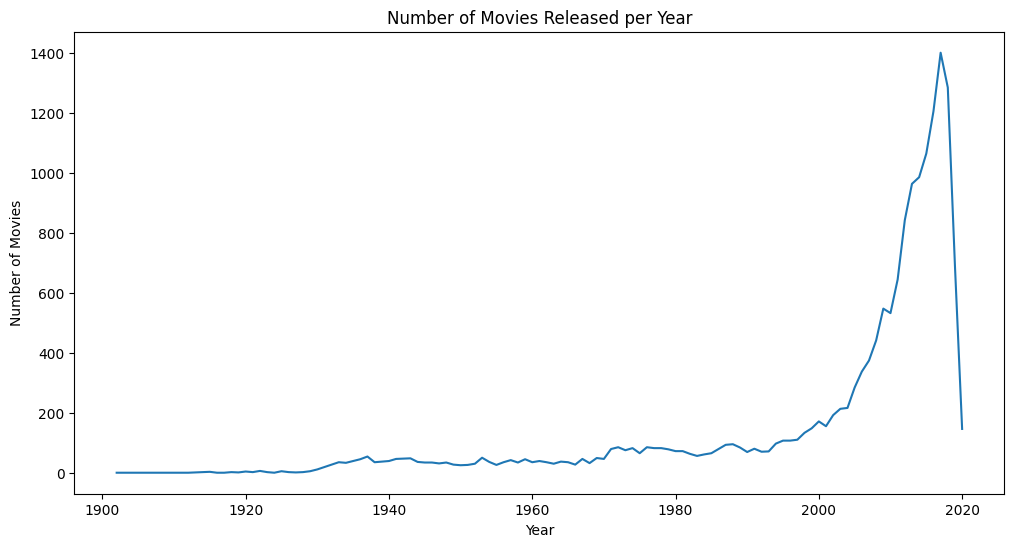

In [22]:
movies_per_year = df['Year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values)
plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

OBSERVATION:

From early 2000s the no.of movies that got released are more

Which platform has the most movies?

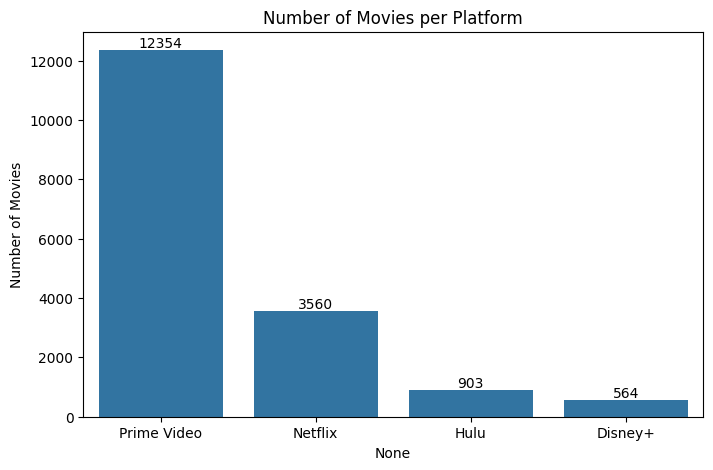

In [23]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
platform_counts = df[platforms].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
a=sns.barplot(x=platform_counts.index, y=platform_counts.values)
for i in a.containers:
    a.bar_label(i)
plt.title("Number of Movies per Platform")
plt.ylabel("Number of Movies")
plt.show()

OBSERVATION:

Prime Video Platforms holds the highest movies and disney holds the least

Which platform hosts higher-rated movies according to viewers?

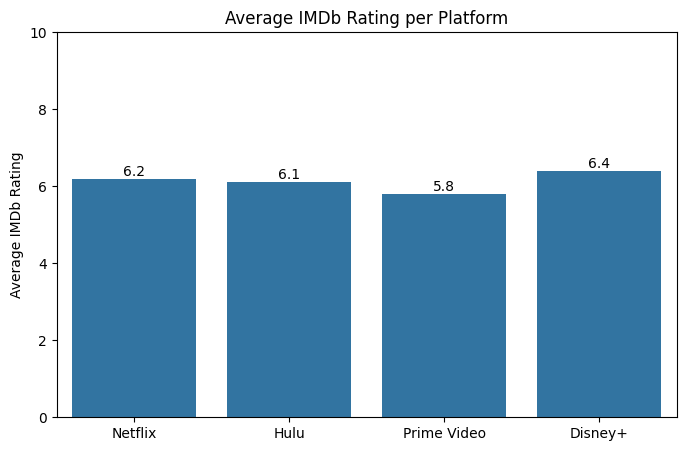

In [24]:
platforms = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']
platform_ratings = {}
for p in platforms:
    platform_ratings[p] = df[df[p] == 1]['IMDb'].mean().round(1)
plt.figure(figsize=(8,5))
a=sns.barplot(x=list(platform_ratings.keys()), y=list(platform_ratings.values()))
for i in a.containers:
    a.bar_label(i)
plt.title("Average IMDb Rating per Platform")
plt.ylabel("Average IMDb Rating")
plt.ylim(0,10)
plt.show()

OSERVATION:

As Prime video has more movies maybe the rating might have been affected

can say no.of movies is directly proportional to rating

Disney + preffers Quality over Quantity

Which movies have the biggest gap between audience and critics ratings?

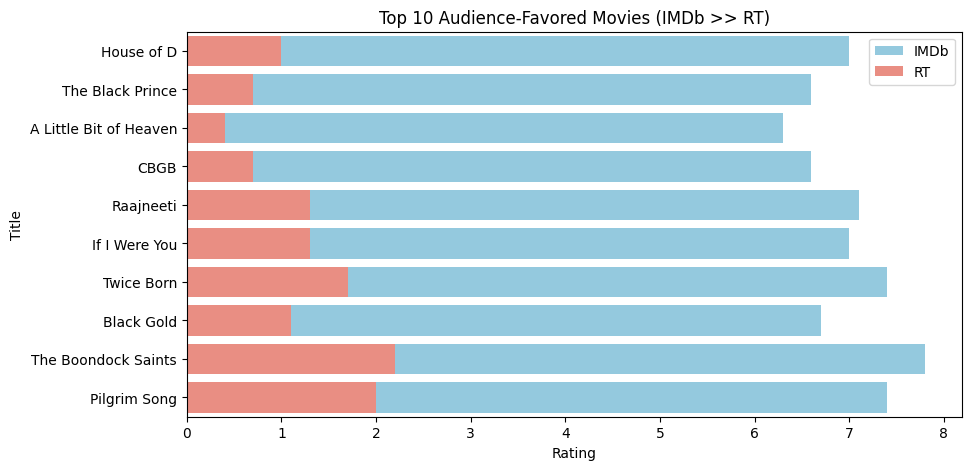

In [25]:
df_temp = df.assign(Rating_Diff = df['IMDb'] - df['Rotten Tomatoes'])
top_audience = df_temp.sort_values('Rating_Diff', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='IMDb', y='Title', data=top_audience, color='skyblue', label='IMDb')
sns.barplot(x='Rotten Tomatoes', y='Title', data=top_audience, color='salmon', label='RT')
plt.title("Top 10 Audience-Favored Movies (IMDb >> RT)")
plt.legend()
plt.xlabel("Rating")
plt.show()


OBSERVATION:

There is a lot of difference b/w Imdb and rotten tomatoes rating for the same movies



# Conclusion

Prime vedio chooses critics over audienece 

Disney chooses audience opinions 

if the platfroms takes balanced ratings from both then it can make the higest profit


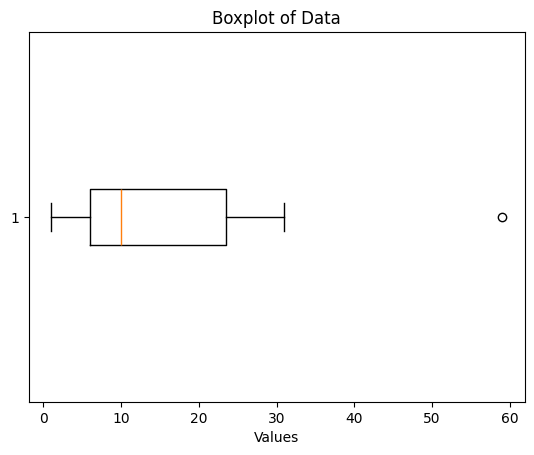

In [26]:
data = [10, 31, 10, 16, 2, 59, 1]

plt.boxplot(data, vert=False)
plt.title("Boxplot of Data")
plt.xlabel("Values")
plt.show()